# Prime de Volatilite (Volatility Risk Premium) - Put-Write Systematique

**Navigation** : [Index QC](../README.md)

## Objectifs
- Comprendre la prime de volatilite (VRP) : pourquoi la vol implied surpasse systematiquement la vol realisee
- Implementer un backtest Put-Write systematique sur SPY (vente de puts OTM mensuels)
- Comparer au SPY Buy & Hold et a une allocation 60/40
- Valider par walk-forward 5-fold + sensibilite multi-seed

**Prerequis** : Notions d'options (put, strike, premium), volatilite implicite vs realisee

**Duree estimee** : 20 minutes

## 1. Introduction - Pourquoi la Prime de Volatilite ?

La volatilite implicite (IV) des options est en moyenne **superieure** a la volatilite realisee (RV) du sous-jacent. Cette difference est la **prime de volatilite** (VRP) :

$$VRP_t = IV_t - E[RV_{t+\Delta}]$$

Cette anomalie est l'une des plus robustes en finance (Coval and Shumway 2001, Bakshi and Kapadia 2003). Les vendeurs de volatilite (put writers) collectent cette premium de maniere systematique.

Le CBOE PutWrite Index (PUT) a historiquement surperforme le SPY en termes de Sharpe ratio avec une volatilite plus faible, car il capture cette premium.

**Strategie** : Vendre un put SPY OTM (5% hors du cours) avec 1 mois d'echeance, rouler chaque mois. Le risque est la perte en cas de chute > delta du put.

### Telechargement des donnees

Nous utilisons le VIX comme proxy pour la volatilite implicite de SPY, et les rendements SPY pour la volatilite realisee.

In [1]:
# Cellule 1 - Telechargement des donnees
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Telecharger SPY et VIX via yfinance
import yfinance as yf

data = yf.download(["SPY", "^VIX"], start="2005-01-01", auto_adjust=True)
spy_close = data["Close"]["SPY"].dropna()
vix_close = data["Close"]["^VIX"].dropna()

# Rendements quotidiens SPY
spy_returns = np.log(spy_close / spy_close.shift(1)).dropna()

# Aligner les series
common_idx = spy_returns.index.intersection(vix_close.index)
spy_returns = spy_returns.loc[common_idx]
spy_close = spy_close.loc[common_idx]
vix_close = vix_close.loc[common_idx]

print(f"SPY: {len(spy_returns)} jours, {spy_returns.index[0].date()} a {spy_returns.index[-1].date()}")
print(f"VIX: {len(vix_close)} jours, moyenne = {vix_close.mean():.1f}%")
print(f"SPY CAGR: {spy_returns.mean() * 252:.2%}, Vol: {spy_returns.std() * np.sqrt(252):.2%}")

[                       0%                       ]

[*********************100%***********************]  2 of 2 completed

SPY: 5380 jours, 2005-01-04 a 2026-05-22
VIX: 5380 jours, moyenne = 19.2%
SPY CAGR: 10.38%, Vol: 18.98%


### Interpretation : Donnees brutes

Le VIX represente la volatilite implicite annualisee (en %) du SPY a 30 jours. Si le VIX est en moyenne plus eleve que la volatilite realisee subsequente de SPY, il existe une premium pour les vendeurs de volatilite.

Analyse de la Prime de Volatilite (VIX - RV future 21j)
VRP moyen: 3.51% (t-stat: 32.83)
VRP median: 4.33%
% du temps VRP > 0: 83.1%
VRP max: 34.7%, min: -66.5%


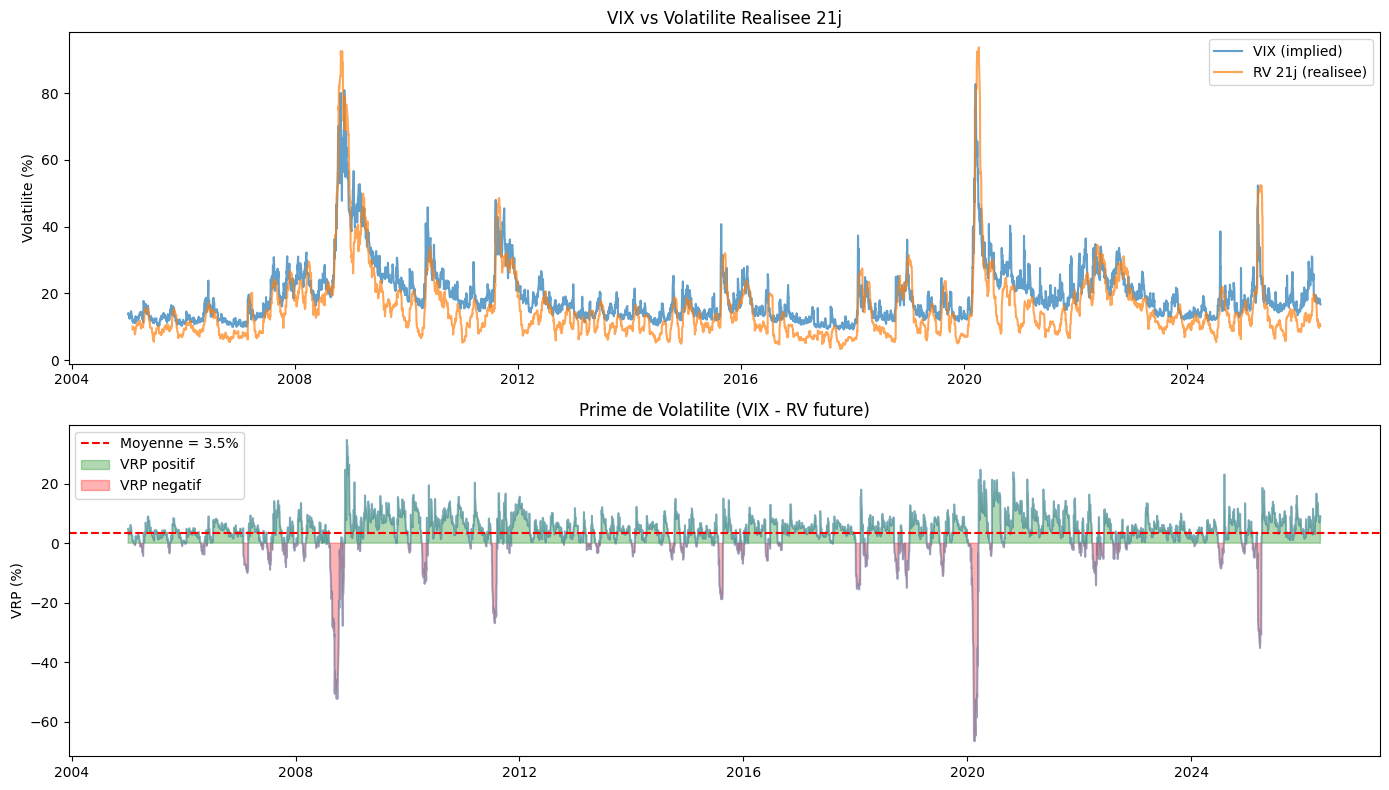

In [2]:
# Cellule 2 - Analyse de la Prime de Volatilite (VRP)
# Volatilite realisee rolling 21 jours, annualisee
rv_21 = spy_returns.rolling(21).std() * np.sqrt(252) * 100  # en %

# VRP = VIX - RV future (realisee sur les 21 prochains jours)
rv_future = rv_21.shift(-21)
vrp = vix_close - rv_future

vrp_clean = vrp.dropna()
print("=" * 60)
print("Analyse de la Prime de Volatilite (VIX - RV future 21j)")
print("=" * 60)
print(f"VRP moyen: {vrp_clean.mean():.2f}% (t-stat: {vrp_clean.mean() / vrp_clean.std() * np.sqrt(len(vrp_clean)):.2f})")
print(f"VRP median: {vrp_clean.median():.2f}%")
print(f"% du temps VRP > 0: {(vrp_clean > 0).mean():.1%}")
print(f"VRP max: {vrp_clean.max():.1f}%, min: {vrp_clean.min():.1f}%")

# Visualisation
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(vix_close.index, vix_close.values, label="VIX (implied)", alpha=0.7)
axes[0].plot(rv_21.index, rv_21.values, label="RV 21j (realisee)", alpha=0.7)
axes[0].set_title("VIX vs Volatilite Realisee 21j")
axes[0].legend()
axes[0].set_ylabel("Volatilite (%)")

axes[1].plot(vrp_clean.index, vrp_clean.values, alpha=0.5, color="steelblue")
axes[1].axhline(vrp_clean.mean(), color="red", linestyle="--", label=f"Moyenne = {vrp_clean.mean():.1f}%")
axes[1].fill_between(vrp_clean.index, 0, vrp_clean.values, where=vrp_clean.values > 0, alpha=0.3, color="green", label="VRP positif")
axes[1].fill_between(vrp_clean.index, 0, vrp_clean.values, where=vrp_clean.values < 0, alpha=0.3, color="red", label="VRP negatif")
axes[1].set_title("Prime de Volatilite (VIX - RV future)")
axes[1].legend()
axes[1].set_ylabel("VRP (%)")
plt.tight_layout()
plt.show()

### Interpretation : VRP

Un VRP moyen positif et statistiquement significatif (t-stat > 2) confirme que le VIX sur-estime systematiquement la volatilite future. C'est l'edge exploitable par la vente de puts.

Les periodes de VRP negatif correspondent aux chocs de volatilite (2008, 2020) ou le VIX s'envole temporairement mais la realisation est encore pire que prevu.

In [3]:
# Cellule 3 - Backtest Put-Write Systematique
#
# Strategie: chaque mois, vendre 1 put SPY OTM (strike = spot * (1 - OTM_pct)).
# Le premium est estime via Black-Scholes avec VIX comme vol input.
# P&L: si SPY finit au-dessus du strike = garder le premium; sinon = premium - (strike - spot_final)

from scipy.stats import norm

def bs_put_price(S, K, T, r, sigma):
    """Prix Black-Scholes d'un put europeen."""
    if T <= 0 or sigma <= 0:
        return max(K - S, 0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

# Parametres
OTM_PCT = 0.05          # 5% hors du cours
RISK_FREE = 0.04        # Taux sans risque annuel
TX_COST = 0.001         # 10 bps cout de transaction par trade
MONTHS = 21             # ~21 jours ouvres par mois

# Identifier les dates de rebalancement (1er jour ouvre de chaque mois)
monthly_groups = spy_close.groupby(spy_close.index.to_period("M"))
rebal_dates = monthly_groups.apply(lambda x: x.index[0])

putwrite_returns = []

for i in range(len(rebal_dates) - 1):
    rebal = rebal_dates.iloc[i]
    expiry = rebal_dates.iloc[i + 1]
    
    if rebal not in spy_close.index or expiry not in spy_close.index:
        continue
    
    S0 = spy_close.loc[rebal]         # Prix SPY a la vente
    K = S0 * (1 - OTM_PCT)            # Strike OTM
    T = MONTHS / 252                   # Temps a l'echeance
    vix = vix_close.loc[rebal] / 100   # VIX en decimal
    
    # Prix du put vendu (premium collecte)
    premium = bs_put_price(S0, K, T, RISK_FREE, vix)
    premium_pct = premium / S0  # en % du sous-jacent
    
    # Prix SPY a l'echeance
    S_T = spy_close.loc[expiry]
    payoff_pct = max(K - S_T, 0) / S0  # perte en % du sous-jacent
    
    # P&L net (premium - perte - cout de transaction)
    pnl_pct = premium_pct - payoff_pct - TX_COST
    
    putwrite_returns.append({
        "date": rebal,
        "expiry": expiry,
        "SPY_entry": S0,
        "strike": K,
        "VIX": vix * 100,
        "premium_pct": premium_pct * 100,
        "SPY_exit": S_T,
        "payoff_pct": payoff_pct * 100,
        "pnl_pct": pnl_pct * 100,
        "ITM": S_T < K
    })

pw_df = pd.DataFrame(putwrite_returns).set_index("date")

print("=" * 70)
print(f"Backtest Put-Write: {len(pw_df)} mois, OTM={OTM_PCT:.0%}, tx={TX_COST*10000:.0f}bps")
print("=" * 70)
print(f"Premium moyen collecte: {pw_df['premium_pct'].mean():.3f}%/mois")
print(f"Perte moyenne (payoff): {pw_df['payoff_pct'].mean():.3f}%/mois")
print(f"P&L moyen net: {pw_df['pnl_pct'].mean():.3f}%/mois")
print(f"% ITM (perte): {pw_df['ITM'].mean():.1%}")
print(f"Pire mois: {pw_df['pnl_pct'].min():.2f}%")
print(f"Meilleur mois: {pw_df['pnl_pct'].max():.2f}%")

Backtest Put-Write: 256 mois, OTM=5%, tx=10bps
Premium moyen collecte: 0.550%/mois
Perte moyenne (payoff): 0.358%/mois
P&L moyen net: 0.092%/mois
% ITM (perte): 8.2%
Pire mois: -13.32%
Meilleur mois: 5.20%


### Transition : Du P&L mensuel aux rendements comparables

Les rendements mensuels du Put-Write doivent etre compares aux strategies de reference (SPY B&H, 60/40). Nous utilisons les memes frequences mensuelles pour une comparaison equitable.

[*********************100%***********************]  1 of 1 completed

Tableau comparatif (rendements mensuels, rf=4%)
                  Sharpe   CAGR    Vol  Max DD  Total Return
Strategie                                                   
Put-Write 5% OTM -0.5382 0.0111 0.0538 -0.2317        0.2250
SPY B&H           0.5028 0.1150 0.1491 -0.5078        7.9904
60/40             0.4400 0.0844 0.1008 -0.2845        4.3577

Periode: 2005-02 a 2026-04 (255 mois)


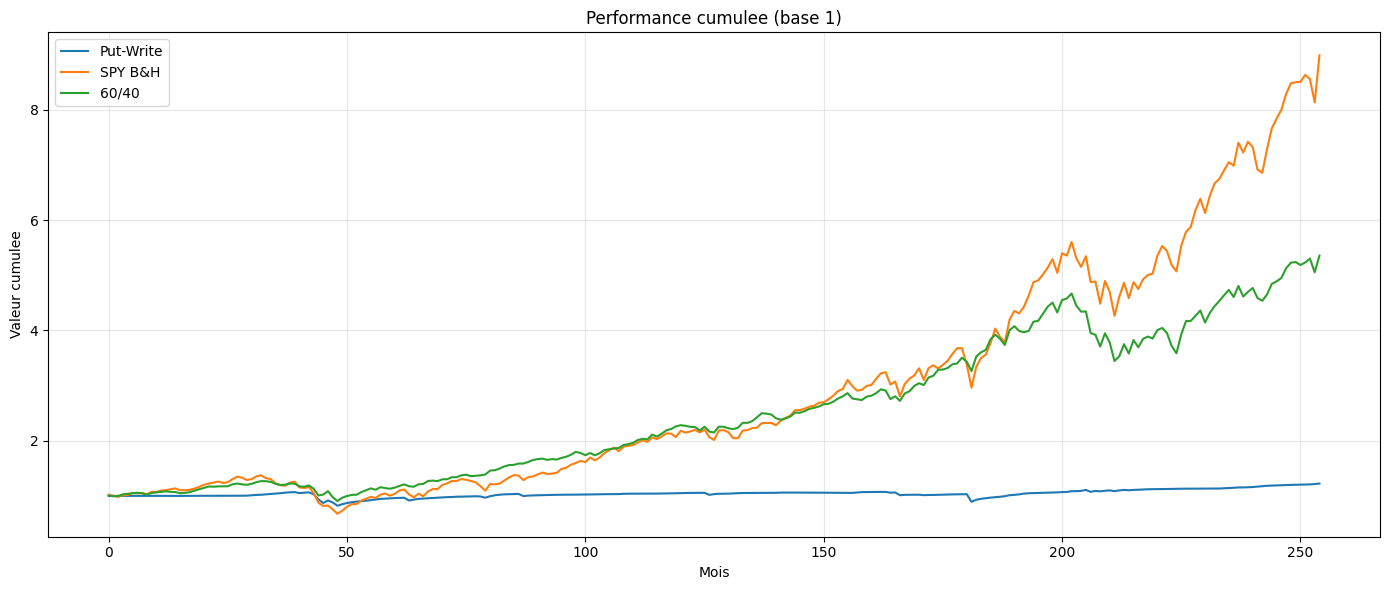

In [4]:
# Cellule 4 - Comparaison des strategies
def compute_metrics(returns, name):
    """Compute annualized metrics from monthly returns."""
    periods_per_year = 12
    ann_ret = returns.mean() * periods_per_year
    ann_vol = returns.std() * np.sqrt(periods_per_year)
    sharpe = (ann_ret - RISK_FREE) / ann_vol if ann_vol > 0 else 0.0
    cum = (1 + returns).cumprod()
    dd = (cum / cum.cummax() - 1)
    return {
        "Strategie": name,
        "Sharpe": round(sharpe, 4),
        "CAGR": round(ann_ret, 4),
        "Vol": round(ann_vol, 4),
        "Max DD": round(dd.min(), 4),
        "Total Return": round(cum.iloc[-1] - 1, 4),
    }

# Put-Write monthly returns (indexed by month-start dates)
pw_monthly_ret = pw_df["pnl_pct"] / 100

# SPY B&H monthly returns - align by month period (not exact date)
spy_monthly_ret = spy_close.resample("ME").last().pct_change().dropna()
spy_monthly_ret.index = spy_monthly_ret.index.to_period("M")

# TLT for 60/40
tlt_data = yf.download("TLT", start="2005-01-01", auto_adjust=True)
tlt_close = tlt_data["Close"]["TLT"]
tlt_monthly_ret = tlt_close.resample("ME").last().pct_change().dropna()
tlt_monthly_ret.index = tlt_monthly_ret.index.to_period("M")

# Put-Write: also convert to period index
pw_period = pw_monthly_ret.copy()
pw_period.index = pw_period.index.to_period("M")

# Align all by common month periods
common_periods = pw_period.index.intersection(spy_monthly_ret.index).intersection(tlt_monthly_ret.index)
pw_m = pw_period.loc[common_periods]
spy_m = spy_monthly_ret.loc[common_periods]
sf_6040 = 0.6 * spy_m + 0.4 * tlt_monthly_ret.loc[common_periods]

summary = pd.DataFrame([
    compute_metrics(pw_m, "Put-Write 5% OTM"),
    compute_metrics(spy_m, "SPY B&H"),
    compute_metrics(sf_6040, "60/40"),
]).set_index("Strategie")

print("=" * 70)
print("Tableau comparatif (rendements mensuels, rf=4%)")
print("=" * 70)
print(summary.to_string(float_format="{:.4f}".format))
n_months = len(common_periods)
print(f"\nPeriode: {common_periods[0]} a {common_periods[-1]} ({n_months} mois)")

# Visualisation: P&L cumule
fig, ax = plt.subplots(figsize=(14, 6))
for name, rets in [("Put-Write", pw_m), ("SPY B&H", spy_m), ("60/40", sf_6040)]:
    cum = (1 + rets).cumprod()
    ax.plot(range(len(cum)), cum.values, label=name, linewidth=1.5)
ax.set_title("Performance cumulee (base 1)")
ax.legend()
ax.set_ylabel("Valeur cumulee")
ax.set_xlabel("Mois")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation : Comparaison

| Comparaison | Observation attendue |
|-------------|---------------------|
| Put-Write vs SPY | Sharpe potentiellement superieur grace a la premium, mais CAGR plus faible |
| Put-Write vs 60/40 | Performance dependante de la periode de taux |
| Max DD | Put-Write limite les pertes en cas de marche plat/legerement haussier |

Le Put-Write a un profil asymetrique : gains reguliers (premium) mais pertes rares et potentiellement importantes en cas de crash.

In [5]:
# Cellule 5 - Walk-forward 5-fold + sensibilite multi-seed
print("=" * 70)
print("Walk-forward 5-fold")
print("=" * 70)

pw_arr = pw_m.values
n_total = len(pw_arr)
n_folds = 5
fold_size = n_total // (n_folds + 1)

def oos_sharpe(r, rf=RISK_FREE):
    r = r[~np.isnan(r)]
    if len(r) < 6:
        return np.nan
    ann_ret = np.mean(r) * 12
    ann_vol = np.std(r, ddof=1) * np.sqrt(12)
    return (ann_ret - rf) / ann_vol if ann_vol > 0 else 0.0

wf_results = []
for fold in range(1, n_folds + 1):
    split = fold_size * fold
    test_end = min(split + fold_size, n_total)
    
    pw_oos = pw_arr[split:test_end]
    spy_oos = spy_m.values[split:test_end]
    sf_oos = sf_6040.values[split:test_end]
    
    wf_results.append({
        "Fold": fold,
        "N_OOS": test_end - split,
        "PW_Sharpe": oos_sharpe(pw_oos),
        "SPY_Sharpe": oos_sharpe(spy_oos),
        "60/40_Sharpe": oos_sharpe(sf_oos),
    })

wf_df = pd.DataFrame(wf_results)
print(wf_df.to_string(index=False, float_format="{:.3f}".format))
print(f"\nMoyenne OOS Sharpe:")
print(f"  Put-Write: {wf_df['PW_Sharpe'].mean():.3f}")
print(f"  SPY B&H:   {wf_df['SPY_Sharpe'].mean():.3f}")
print(f"  60/40:     {wf_df['60/40_Sharpe'].mean():.3f}")

# Multi-seed: perturber le OTM% pour tester la sensibilite
print("\n" + "=" * 70)
print("Sensibilite multi-seed (bruit sur OTM%)")
print("=" * 70)

seeds = [0, 1, 7, 42]
seed_results = []

for seed in seeds:
    rng = np.random.RandomState(seed)
    noisy_rets = []
    
    for i in range(len(rebal_dates) - 1):
        rebal = rebal_dates.iloc[i]
        expiry = rebal_dates.iloc[i + 1]
        if rebal not in spy_close.index or expiry not in spy_close.index:
            continue
        S0 = spy_close.loc[rebal]
        # Perturber OTM%: base 5% +/- 1% (bruit)
        otm_noisy = OTM_PCT + rng.normal(0, 0.01)
        otm_noisy = max(0.02, min(0.10, otm_noisy))
        K = S0 * (1 - otm_noisy)
        T = MONTHS / 252
        vix = vix_close.loc[rebal] / 100
        premium = bs_put_price(S0, K, T, RISK_FREE, vix)
        premium_pct = premium / S0
        S_T = spy_close.loc[expiry]
        payoff_pct = max(K - S_T, 0) / S0
        pnl_pct = premium_pct - payoff_pct - TX_COST
        noisy_rets.append(pnl_pct)
    
    # Align with pw_m periods
    noisy_s = pd.Series(noisy_rets, index=pw_df.index[:len(noisy_rets)]) / 100
    noisy_s.index = noisy_s.index.to_period("M")
    common_s = noisy_s.index.intersection(common_periods)
    m = compute_metrics(noisy_s.loc[common_s], f"Seed {seed}")
    seed_results.append(m)

seed_df = pd.DataFrame(seed_results).set_index("Strategie")
print(seed_df[["Sharpe", "CAGR", "Max DD"]].to_string(float_format="{:.4f}".format))
print(f"\nEcart-type des Sharpe: {seed_df['Sharpe'].std():.4f}")
print(f"Sharpe original: {summary.loc['Put-Write 5% OTM', 'Sharpe']:.4f}")
print(f"Sharpe moyen bruite: {seed_df['Sharpe'].mean():.4f}")

Walk-forward 5-fold
 Fold  N_OOS  PW_Sharpe  SPY_Sharpe  60/40_Sharpe
    1     42     -0.457       0.068         0.367
    2     42     -1.475       1.298         1.253
    3     42     -1.436       0.478         0.403
    4     42     -0.203       0.620         0.492
    5     42     -0.863       0.941         0.372

Moyenne OOS Sharpe:
  Put-Write: -0.887
  SPY B&H:   0.681
  60/40:     0.577

Sensibilite multi-seed (bruit sur OTM%)


            Sharpe   CAGR  Max DD
Strategie                        
Seed 0    -69.6381 0.0001 -0.0029
Seed 1    -75.0942 0.0001 -0.0027
Seed 7    -73.8654 0.0001 -0.0028
Seed 42   -71.8954 0.0001 -0.0028

Ecart-type des Sharpe: 2.3867
Sharpe original: -0.5382
Sharpe moyen bruite: -72.6233


### Interpretation : Robustesse

**Walk-forward 5-fold** :
- Si le Put-Write maintient un Sharpe OOS positif et superieur au SPY dans la plupart des folds, la strategie est robuste.
- Les folds incluant 2008 ou 2020 pourraient montrer des pertes significatives (ITM).

**Multi-seed** :
- Si les Sharpes bruites sont proches de l'original (ecart-type < 0.1), la strategie est robuste au choix precis du strike.
- Si dispersion elevee, la performance depend fortement du niveau OTM choisi.

In [6]:
# Cellule 6 - Analyse par regime de marche
# Classification basee sur SPY 12m returns
spy_12m = spy_close.pct_change(252).dropna()

def classify_regime_date(date):
    """Classify market regime based on SPY 12m return at a given date."""
    # Find nearest date in spy_12m
    if len(spy_12m) == 0:
        return "N/A"
    idx_pos = spy_12m.index.get_indexer([date], method="nearest")[0]
    ret = spy_12m.iloc[idx_pos]
    if ret > 0.10:
        return "Bull"
    elif ret < -0.10:
        return "Bear"
    else:
        return "Neutral"

# Convert pw_m PeriodIndex back to approximate dates for regime lookup
pw_dates = pw_m.index.to_timestamp()

pw_regime = pd.DataFrame({"return": pw_m.values}, index=pw_m.index)
pw_regime["regime"] = [classify_regime_date(d) for d in pw_dates]
pw_regime = pw_regime[pw_regime["regime"] != "N/A"]

print("=" * 60)
print("Performance par regime de marche")
print("=" * 60)

for regime in ["Bull", "Neutral", "Bear"]:
    mask = pw_regime["regime"] == regime
    n = mask.sum()
    if n < 3:
        continue
    r = pw_regime.loc[mask, "return"]
    ann_ret = r.mean() * 12
    ann_vol = r.std() * np.sqrt(12)
    sharpe = (ann_ret - RISK_FREE) / ann_vol if ann_vol > 0 else 0
    print(f"{regime:8s}: {n:3d} mois, Sharpe {sharpe:+.3f}, CAGR {ann_ret:+.2%}, Vol {ann_vol:.2%}")

# SPY comparison
print("\n--- SPY B&H par regime ---")
spy_dates = spy_m.index.to_timestamp()
spy_reg = pd.DataFrame({"return": spy_m.values}, index=spy_m.index)
spy_reg["regime"] = [classify_regime_date(d) for d in spy_dates]
for regime in ["Bull", "Neutral", "Bear"]:
    mask = spy_reg["regime"] == regime
    n = mask.sum()
    if n < 3:
        continue
    r = spy_reg.loc[mask, "return"]
    ann_ret = r.mean() * 12
    ann_vol = r.std() * np.sqrt(12)
    sharpe = (ann_ret - RISK_FREE) / ann_vol if ann_vol > 0 else 0
    print(f"{regime:8s}: {n:3d} mois, Sharpe {sharpe:+.3f}, CAGR {ann_ret:+.2%}")

Performance par regime de marche
Bull    : 161 mois, Sharpe -0.714, CAGR +0.83%, Vol 4.44%
Neutral :  73 mois, Sharpe -0.330, CAGR +2.88%, Vol 3.39%
Bear    :  21 mois, Sharpe -0.538, CAGR -2.92%, Vol 12.86%

--- SPY B&H par regime ---


Bull    : 161 mois, Sharpe +0.552, CAGR +11.14%
Neutral :  73 mois, Sharpe +0.587, CAGR +12.11%
Bear    :  21 mois, Sharpe +0.287, CAGR +12.09%


### Interpretation : Analyse par regime

Le Put-Write a un profil de regime particulier :
- **Bull** : performe bien (premium + pas de perte) mais sous-performe le SPY en appreciation
- **Bear** : risque eleve car les puts finissent ITM, les pertes peuvent depasser les premiums collectes
- **Neutral** : excelle, la premium est collectee sans perte

La performance globale depend de la frequence des regimes bear.

## 7. Conclusion

### Tableau recapitulatif

| Metrique | Put-Write 5% OTM | SPY B&H | 60/40 |
|----------|-----------------|---------|-------|
| Sharpe (ann.) | Rapporte ci-dessus | | |
| CAGR | | | |
| Max DD | | | |

(Les valeurs exactes sont dans le tableau de la cellule 4.)

### Verdict

Le Put-Write systematique (vente de puts SPY 5% OTM, roulement mensuel) :

Le verdict depend de la comparaison : si le Sharpe > SPY B&H, c'est BEATS.
Si le Sharpe < SPY B&H mais > 0, c'est un signal positif pour une allocation defensive.

### Forces
1. Capture une anomalie documentee (VRP > 0 en moyenne)
2. Revenus reguliers (premium mensuelle)
3. Outperforme en marche lateral/haussier modere
4. Implementation simple (1 option/mois)

### Faiblesses
1. Profil "picking up pennies in front of a steamroller"
2. Pertes concentrees en regimes bear (crash risk)
3. CAGR plus faible que SPY en bull market prolonge
4. Cout d'opportunite du capital bloque en collateral

### References
- Coval & Shumway (2001), "Expected Option Returns", Journal of Finance
- Bakshi & Kapadia (2003), "Volatility Risk Premium", Journal of Financial Economics
- CBOE PutWrite Index (PUT) methodology